# 01 — Analytical transfer function (OPA365 Fig. 8-6)

Three-pole, ~20 kHz, unity-gain **Sallen–Key** low-pass filter from the OPA365 datasheet.

This notebook derives and evaluates:

1. Ideal $H_{\mathrm{vin}}(s)=V_{\mathrm{out}}/V_{\mathrm{in}}$
2. **Full AC superposition** of four sources: $V_{\mathrm{in}}$, $V_{OS}$, $I_{B+}$, $I_{B-}$
3. DC error budget and key metrics ($f_c$, gain @ 20 kHz, …)

All $R$ and $C$ values are variables in the parameter cell below.

Nominal R and C values are the ones published in Texas Instruments OPAx365 datasheet **SBOS365G, Figure 8-6**. The schematic below is redrawn from those values. This repository does not include the datasheet PDF or the TI SPICE macromodel.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


## Topology

```
VIN ── R1 ── n1 ── R2 ── n2 ── R3 ── n3 ──(+) OPA365 ── VOUT
          │         │         │          │
         C1        C3        C2         (−) tied to VOUT
         gnd    (to VOUT)    gnd
```

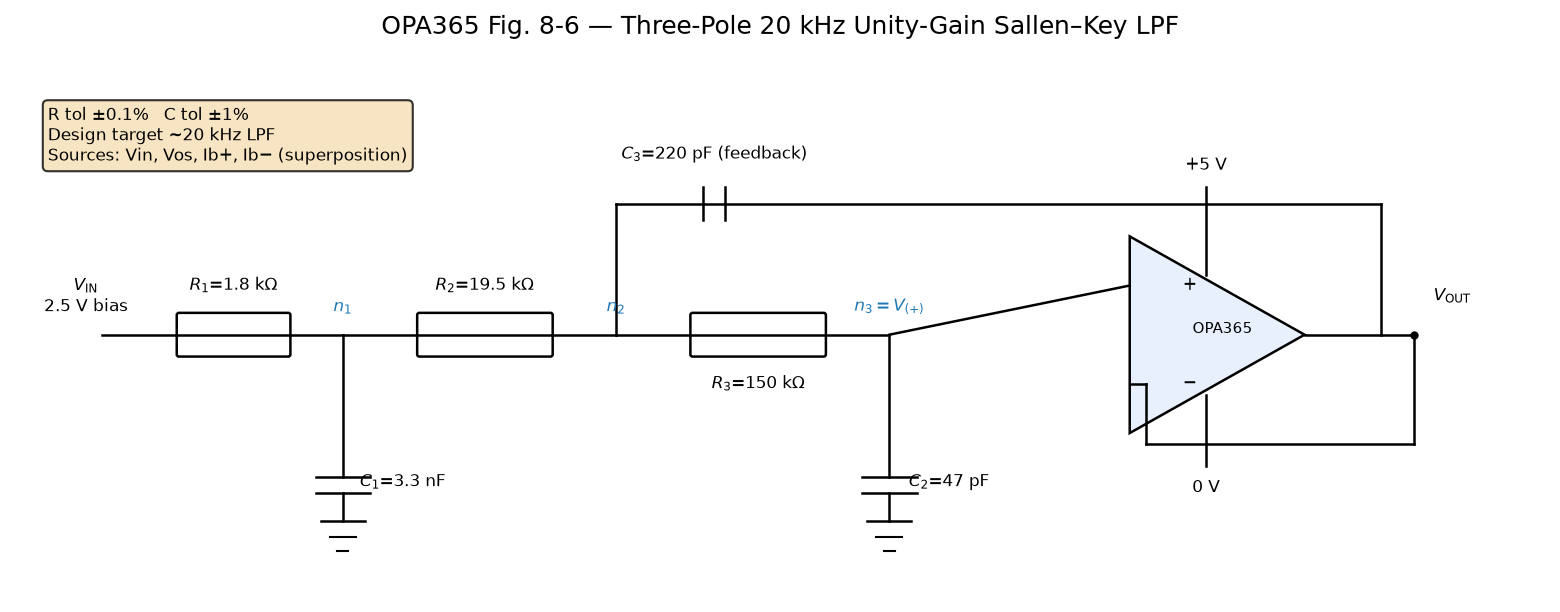

Saved: .\results\figures\fig86_schematic.png


In [2]:
spath = schematic.draw_fig86_schematic(FIG / "fig86_schematic.png", p)
from IPython.display import Image, display
display(Image(filename=str(spath), width=900))
print("Saved:", spath)

## Ideal transfer function

With infinite open-loop gain and $V_{OS}=I_{B+}=I_{B-}=0$, the network is a
third-order low-pass with **DC gain = 1**:

$$
H_{\mathrm{vin}}(s)=\frac{V_{\mathrm{out}}}{V_{\mathrm{in}}}
=\frac{1}{a_3 s^3+a_2 s^2+a_1 s+1}
$$

Coefficients $a_i$ are identified from the nodal admittance system
(see `opamp_design.analysis`).

In [3]:
a3, a2, a1, a0 = analysis.ideal_den_coefficients(p)
print(f"a3 = {a3:.6e}")
print(f"a2 = {a2:.6e}")
print(f"a1 = {a1:.6e}")
print(f"a0 = {a0:.6e}")

from IPython.display import Math, display
display(Math(analysis.latex_transfer_ideal(p)))
display(Math(analysis.latex_superposition()))

m = analysis.summary_metrics(p)
display(pd.DataFrame(analysis.format_metrics_table(m), columns=["Metric", "Value"]))

a3 = 1.796523e-16
a2 = 8.035731e-11
a1 = 1.399110e-05
a0 = 1.000000e+00


<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Metric,Value
0,f_c (-3 dB),19.77 kHz
1,Passband |H|,0.999993
2,Passband |H| dB,-0.0001 dB
3,|H| @ f_design,0.700653
4,|H| @ f_design dB,-3.0899 dB
5,∠H @ f_design,-100.86°
6,DC Vout (mid bias),2.500000 V


## Four-source AC superposition

Ideal infinite-gain constraint: $V_{(+)}-V_{(-)}=V_{OS}$ with $V_{(-)}=V_{\mathrm{out}}$ gives
$V_{\mathrm{out}}=V_{(+)}-V_{OS}$.

$$
V_{\mathrm{out}}(s)
=H_{\mathrm{vin}}(s)\,V_{\mathrm{in}}(s)
+H_{V_{OS}}(s)\,V_{OS}
+H_{I_{B+}}(s)\,I_{B+}
+H_{I_{B-}}(s)\,I_{B-}
$$

- $H_{\mathrm{vin}}$, $H_{V_{OS}}$: dimensionless  
- $H_{I_{B\pm}}$: ohms (V/A)  
- For an ideal voltage-mode op-amp, $H_{I_{B-}}=0$ (bias into the output pin is absorbed by the VCVS). $I_{B+}$ produces a small series drop through $R_1+R_2+R_3$ at DC.

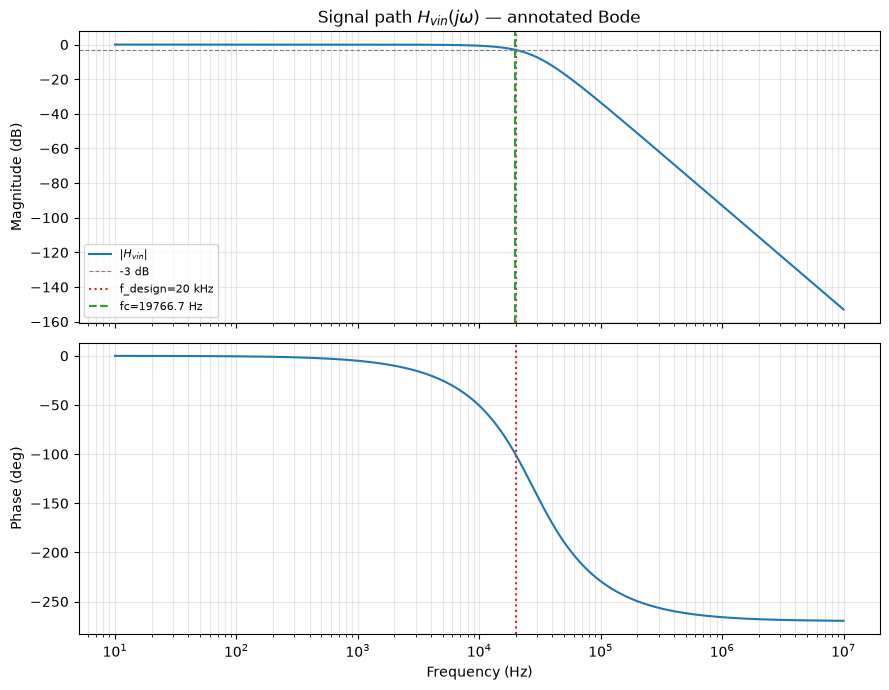

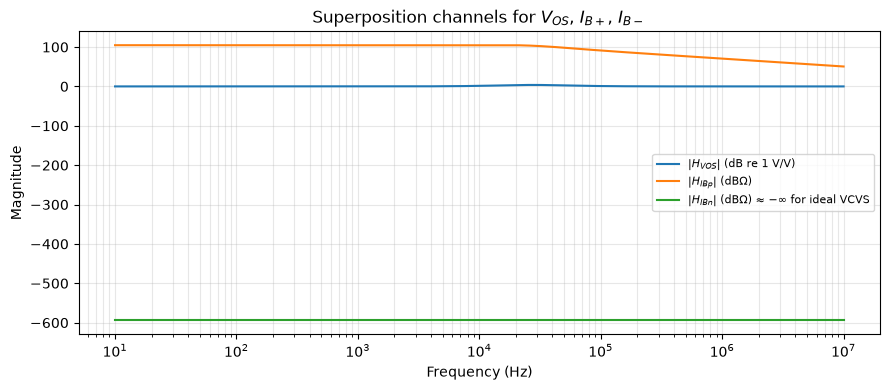

In [4]:
f = analysis.frequency_grid(10, 10e6, 401)
chs = analysis.superposition_bode(p, f_hz=f)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Vin channel
axes[0].semilogx(chs["vin"].f_hz, chs["vin"].mag_db, label=r"$|H_{vin}|$")
axes[0].axhline(-3, color="gray", ls="--", lw=0.8, label="-3 dB")
axes[0].axvline(p.op.f_design_hz, color="C3", ls=":", label=f"f_design={p.op.f_design_hz/1e3:g} kHz")
fc = analysis.find_fc_3db(p, f_hz=f)
axes[0].axvline(fc, color="C2", ls="--", label=f"fc={fc:.1f} Hz")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title("Signal path $H_{vin}(j\\omega)$ — annotated Bode")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(loc="best", fontsize=8)

axes[1].semilogx(chs["vin"].f_hz, chs["vin"].phase_unwrapped_deg, color="C0")
axes[1].axvline(p.op.f_design_hz, color="C3", ls=":")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (deg)")
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "01_bode_Hvin.png", dpi=150)
plt.show()

# Non-ideal channels
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(chs["vos"].f_hz, chs["vos"].mag_db, label=r"$|H_{VOS}|$ (dB re 1 V/V)")
# Ibp in dBΩ = 20 log10 |Z|
ibp_db = 20 * np.log10(np.maximum(chs["ibp"].mag, 1e-30))
ibn_db = 20 * np.log10(np.maximum(chs["ibn"].mag, 1e-30) + 1e-30)
ax.semilogx(chs["ibp"].f_hz, ibp_db, label=r"$|H_{IBp}|$ (dBΩ)")
ax.semilogx(chs["ibn"].f_hz, ibn_db, label=r"$|H_{IBn}|$ (dBΩ) ≈ −∞ for ideal VCVS")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("Superposition channels for $V_{OS}$, $I_{B+}$, $I_{B-}$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "01_bode_nonideals.png", dpi=150)
plt.show()

## DC error budget at mid-rail bias

In [5]:
budget_typ = analysis.dc_error_budget(p, vos=p.opamp.vos_typ, ibp=p.opamp.ib_typ, ibn=p.opamp.ib_typ)
budget_max = analysis.dc_error_budget(p, vos=p.opamp.vos_max, ibp=p.opamp.ib_max, ibn=p.opamp.ib_max)
display(pd.DataFrame([
    {"case": "typ", **budget_typ},
    {"case": "max", **budget_max},
]))

# Equivalent: Rseries * Ibp
print(f"R1+R2+R3 = {format_eng(p.R1+p.R2+p.R3, 'Ω')}")
print(f"Ibp_max * Rseries = {p.opamp.ib_max * (p.R1+p.R2+p.R3) * 1e6:.3f} µV")

,case,ideal,due_vos,due_ibp,due_ibn,total,error
0,typ,2.5,-0.0001,-3.426000e-08,0.0,2.499900,-0.000100
1,max,2.5,-0.0002,-1.713000e-06,0.0,2.499798,-0.000202


R1+R2+R3 = 171.3 kΩ
Ibp_max * Rseries = 1.713 µV


## Poles

Roots of the denominator polynomial (rad/s). Convert to Hz via $f = |s|/(2\pi)$.

In [6]:
poles = analysis.poles_from_coefficients(p)
df = pd.DataFrame({
    "pole_rad_s": poles,
    "real": poles.real,
    "imag": poles.imag,
    "f_hz": np.abs(poles) / (2 * np.pi),
})
display(df)

,pole_rad_s,real,imag,f_hz
0,-193462.876315+ 0.000000j,-193462.876315,0.000000,30790.573070
1,-126915.285343+112536.545818j,-126915.285343,112536.545818,26996.339695
2,-126915.285343-112536.545818j,-126915.285343,-112536.545818,26996.339695


## Next

- Notebook **02**: ngspice vs analytical  
- Notebook **03**: LTspice vs analytical  

To plug in another netlist later: keep this notebook for the *reference* math, and use `simulate.run_external_netlist` in 02/03 for SPICE-only paths.